In [39]:
import os
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras import layers, Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from utils import preprocess
import random

load and preprocess data

In [34]:
# DATA
image_data = []
steering_data = []

df = pd.read_csv("dataset2/driving_log.csv")

image_paths = df.iloc[:,0].values
steering_angles = df.iloc[:,3].values



In [35]:
image_paths.shape

(12281,)

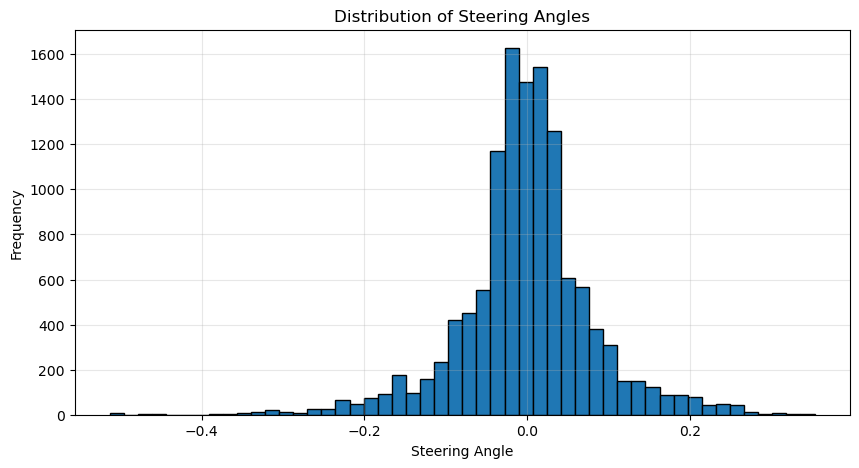

In [36]:
plt.figure(figsize=(10, 5))
plt.hist(steering_angles, bins=50, edgecolor='black')
plt.xlabel('Steering Angle')
plt.ylabel('Frequency')
plt.title('Distribution of Steering Angles')
plt.grid(True, alpha=0.3)
plt.show()

In [40]:
for i in range(len(image_paths)):
    img = cv2.imread(image_paths[i])
    image_data.append(img)

In [41]:
X_train, y_train, X_test, y_test = train_test_split(image_data, steering_angles, test_size=0.2)

In [ ]:
def augment_flip(image, steering_angle):
    flipped_image = cv2.flip(image, 1) # flip horizontally
    flipped_angle = -steering_angle
    return flipped_image, flipped_angle

def augment_brightness(image):
    brightness_factor = np.random.uniform(0.4, 1.2)
    adjusted = (image * brightness_factor).clip(0, 255).astype('uint8')
    return adjusted

def augment_zoom(image, zoom_range=(1, 1.2)):
    zoom = np.random.uniform(zoom_range[0], zoom_range[1])
    h, w = image.shape[:2]
    cx, cy = w // 2, h//2

    M = cv2.getRotationMatrix2D((cx, cy), 0, zoom)

    zoomed = cv2.warpAffine(image, M, (w, h))

    return zoomed

def augment_panning(image):
    print("")


(66, 200, 3)